# LSTM Model: Airport Traffic Forecasting

This notebook trains an LSTM that forecasts flight counts 1, 2, and 3 hours ahead.

- **Part 0:** a light hyperparameter search on the validation set only, to pick the model's architecture settings
- **Part 1:** LSTM on the full dataset, compared with baselines, on the shared test period
- **Part 1B:** the same model retested on two earlier periods, to check the result isn't a fluke of one window
- **Part 2:** traffic-only vs traffic + weather, on the period where weather data exists
- **Part 3:** diagnostics (weather shift, where the seasonal baseline struggled)
- **Part 5:** a plain-language performance report for the airport operations team

Two model variants are compared:
- **LSTM**: predicts the flight count directly from the base traffic features.
- **LSTM (residual)**: also receives the flight count from the same hour one week earlier, and predicts the *deviation* from it, which is then added back. This gives the model a strong starting point (the weekly pattern) so it only has to learn the correction on top.

Baselines: persistence (next hours = current hour), seasonal naive (same hour last week), and seasonal average (mean of the same hour 1 and 2 weeks ago).

All Part 1/2 results are averaged over 5 random seeds. The split is 70/15/15 in time order, no shuffling, 3 boundary rows removed.

**Evaluation metrics:** MAE, RMSE, and **sMAPE** (symmetric mean absolute percentage error), matching the project's evaluation framework. Operational pressure is reported both as a binary high/low flag and as **data-driven NORMAL / HIGH / EXTREME levels found by clustering** historical traffic (not a fixed rule), each with its own recommended action — tuned so EXTREME stays a genuinely rare, busiest-of-the-busy condition.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             precision_recall_fscore_support)

SEEDS = [1, 2, 3, 4, 5]     # use [1] for a quick test run
WINDOW = 24                 # the LSTM looks at the last 24 hours
HORIZON = 3                 # forecast 1, 2, 3 hours ahead
TARGET_COLS = ['target_t1', 'target_t2', 'target_t3']

## Helper functions

- `split_by_time`: same 70/15/15 split as the shared split notebook (3 boundary rows removed).
- `seasonal_reference`: flight counts from the same hour 1 week (or 2 weeks) earlier.
- `make_windows`: builds 24-hour sequences, assigned to a partition by their **target** row. Windows with missing hours or missing values are skipped.
- `run_lstm`: scales the data (scalers fitted on training rows only), trains, and evaluates against the baselines. Architecture (layer sizes, dropout, learning rate, window) is now configurable instead of hard-coded.
- `tune_lstm`: trains ONE hyperparameter configuration and scores it on the **validation set only** — used for Part 0, never for the final reported results.
- `score`: MAE, RMSE, sMAPE.
- `summarize`, `compare_weather`, `pressure_table`: result tables (binary high/low pressure).
- `test_results_table`: a clean, report-ready MAE/RMSE/sMAPE table by forecast horizon, for one model on one dataset.
- `fit_pressure_tiers`, `classify_tier`, `pressure_tier_table`: data-driven NORMAL/HIGH/EXTREME pressure levels. Fine-grained clustering (6 sub-clusters) on training-period traffic is merged into 3 tiers sized so EXTREME stays a rare, busiest-of-the-busy condition (~10% of hours) rather than a near-even split.

In [2]:
DETAILS = {}   # stores test predictions for plots, pressure analysis, and the ops report


def split_by_time(df, horizon=HORIZON):
    """(start, end) row positions of train / validation / test."""
    n = len(df)
    train_end = int(n * 0.70)
    validation_end = int(n * 0.85)
    return (0, train_end - horizon), (train_end, validation_end - horizon), (validation_end, n)


def show_split(name, d):
    (a, b), (c, e), (f, g) = split_by_time(d)
    print(f"{name}: {len(d)} rows")
    print(f"  train      {b - a} rows: {d['hour'].iloc[a]}  ->  {d['hour'].iloc[b - 1]}")
    print(f"  validation {e - c} rows: {d['hour'].iloc[c]}  ->  {d['hour'].iloc[e - 1]}")
    print(f"  test       {g - f} rows: {d['hour'].iloc[f]}  ->  {d['hour'].iloc[g - 1]}")


def seasonal_reference(hours, weeks=1):
    """Flight count at (hour + k - 168*weeks) for k = 1, 2, 3  ->  array (n, 3)."""
    hours = pd.DatetimeIndex(hours)
    out = np.empty((len(hours), 3))
    for k in range(3):
        idx = hours + pd.Timedelta(hours=k + 1 - 168 * weeks)
        out[:, k] = count_history.reindex(idx).to_numpy()
    return out


def make_windows(feats, targs, cur, hrs, window, a, b):
    """Windows whose TARGET row is in [a, b). History may reach back into an
    earlier partition (past data only). Windows with missing hours or
    missing values are skipped."""
    bad = np.isnan(feats).any(axis=1) | np.isnan(targs).any(axis=1)
    csum = np.concatenate([[0], np.cumsum(bad)])
    X, y, current, ends = [], [], [], []
    for end in range(max(a, window - 1), b):
        start = end - window + 1
        if hrs[end] - hrs[start] != window - 1:      # gap in the timeline
            continue
        if csum[end + 1] - csum[start] > 0:          # NaN inside the window
            continue
        X.append(feats[start:end + 1])
        y.append(targs[end])
        current.append(cur[end])
        ends.append(end)
    return np.array(X), np.array(y), np.array(current), np.array(ends)


def score(true, pred):
    """MAE, RMSE, sMAPE (%) — NaNs in pred are dropped first."""
    m = ~np.isnan(pred)
    t, p = true[m], pred[m]
    denom = np.abs(t) + np.abs(p)
    smape = np.mean(np.where(denom == 0, 0.0, 2 * np.abs(p - t) / denom)) * 100
    return (mean_absolute_error(t, p),
            np.sqrt(mean_squared_error(t, p)),
            smape)


def build_model(window, n_features, units1, units2, dropout, learning_rate):
    model = keras.Sequential([
        layers.Input(shape=(window, n_features)),
        layers.LSTM(units1, return_sequences=True),
        layers.Dropout(dropout),
        layers.LSTM(units2),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.Dense(3)                       # t+1, t+2, t+3
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model


def run_lstm(df, feature_cols, run_name, seed, residual=False,
             window=WINDOW, epochs=100, batch_size=64,
             units1=64, units2=32, dropout=0.2, learning_rate=0.001):
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    label = 'LSTM (residual)' if residual else 'LSTM'

    df = df.sort_values('hour').reset_index(drop=True)
    (tr_a, tr_b), (va_a, va_b), (te_a, te_b) = split_by_time(df)

    seas1 = seasonal_reference(df['hour'], 1)
    seas2 = seasonal_reference(df['hour'], 2)
    seas_avg = (seas1 + seas2) / 2

    cols = list(feature_cols)
    if residual:
        for k in range(3):
            df[f'seas_t{k + 1}'] = seas1[:, k]
        cols += ['seas_t1', 'seas_t2', 'seas_t3']

    true_raw = df[TARGET_COLS].to_numpy(dtype=float)
    base = seas1 if residual else np.zeros_like(seas1)
    y_model = true_raw - base            # residual model learns the deviation from last week

    # Scalers fitted on TRAINING rows only (prevents leakage)
    sx = StandardScaler().fit(df.iloc[tr_a:tr_b][cols])
    sy = StandardScaler().fit(y_model[tr_a:tr_b])

    feats = sx.transform(df[cols])
    targs = sy.transform(y_model)
    cur = df['flight_count'].to_numpy(dtype=float)
    hrs = ((df['hour'] - df['hour'].iloc[0]).dt.total_seconds() / 3600).to_numpy()

    X_tr, y_tr, _, _ = make_windows(feats, targs, cur, hrs, window, tr_a, tr_b)
    X_va, y_va, _, _ = make_windows(feats, targs, cur, hrs, window, va_a, va_b)
    X_te, y_te, _, end_te = make_windows(feats, targs, cur, hrs, window, te_a, te_b)

    model = build_model(window, len(cols), units1, units2, dropout, learning_rate)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=epochs,
                        batch_size=batch_size, callbacks=[early_stop], verbose=0)

    # Predictions converted back to real flight counts
    pred = sy.inverse_transform(model.predict(X_te, verbose=0)) + base[end_te]
    true = true_raw[end_te]

    persistence = np.repeat(cur[end_te].reshape(-1, 1), 3, axis=1)
    seasonal = seas1[end_te]
    seasonal_avg = seas_avg[end_te]

    # keep predictions for plots / pressure analysis / ops report
    d = {'hour': df['hour'].iloc[end_te].reset_index(drop=True)}
    for i in range(3):
        d[f'true_{i + 1}'] = true[:, i]
        d[f'pred_{i + 1}'] = pred[:, i]
        d[f'seas_{i + 1}'] = seasonal[:, i]
        d[f'pers_{i + 1}'] = persistence[:, i]
    DETAILS[(run_name, label, seed)] = pd.DataFrame(d)

    rows = []
    for i, h in enumerate(['t+1', 't+2', 't+3']):
        for model_name, p in [(label, pred),
                              ('Persistence', persistence),
                              ('Seasonal naive (168h)', seasonal),
                              ('Seasonal avg (168h+336h)', seasonal_avg)]:
            mae, rmse, smape = score(true[:, i], p[:, i])
            rows.append({'dataset': run_name, 'model': model_name, 'horizon': h,
                         'MAE': mae, 'RMSE': rmse, 'sMAPE': smape,
                         'n_test': len(true), 'seed': seed})

    print(f"done: {run_name} | {label} | seed {seed} | epochs {len(history.history['loss'])}")
    return pd.DataFrame(rows)


def run_seeds(df, cols, run_name, residual, **kwargs):
    """kwargs are passed straight through to run_lstm — e.g. the tuned
    units1/units2/dropout/learning_rate/window from Part 0."""
    return pd.concat([run_lstm(df, cols, run_name, seed=s, residual=residual, **kwargs)
                      for s in SEEDS], ignore_index=True)


def tune_lstm(df, feature_cols, params, seed=1, residual=True, epochs=60, batch_size=64):
    """Train ONE hyperparameter configuration and score it (MAE, averaged
    over t+1/t+2/t+3) on the VALIDATION set only. Used to pick
    hyperparameters in Part 0 — never touches the test set, and never
    feeds into the final reported results directly."""
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    window = params.get('window', WINDOW)
    units1 = params.get('units1', 64)
    units2 = params.get('units2', 32)
    dropout = params.get('dropout', 0.2)
    learning_rate = params.get('learning_rate', 0.001)

    df = df.sort_values('hour').reset_index(drop=True)
    (tr_a, tr_b), (va_a, va_b), (te_a, te_b) = split_by_time(df)

    seas1 = seasonal_reference(df['hour'], 1)
    cols = list(feature_cols)
    if residual:
        for k in range(3):
            df[f'seas_t{k + 1}'] = seas1[:, k]
        cols += ['seas_t1', 'seas_t2', 'seas_t3']

    true_raw = df[TARGET_COLS].to_numpy(dtype=float)
    base = seas1 if residual else np.zeros_like(seas1)
    y_model = true_raw - base

    sx = StandardScaler().fit(df.iloc[tr_a:tr_b][cols])
    sy = StandardScaler().fit(y_model[tr_a:tr_b])

    feats = sx.transform(df[cols])
    targs = sy.transform(y_model)
    cur = df['flight_count'].to_numpy(dtype=float)
    hrs = ((df['hour'] - df['hour'].iloc[0]).dt.total_seconds() / 3600).to_numpy()

    X_tr, y_tr, _, _ = make_windows(feats, targs, cur, hrs, window, tr_a, tr_b)
    X_va, y_va, _, end_va = make_windows(feats, targs, cur, hrs, window, va_a, va_b)

    model = build_model(window, len(cols), units1, units2, dropout, learning_rate)
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                                restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=epochs,
              batch_size=batch_size, callbacks=[early_stop], verbose=0)

    pred = sy.inverse_transform(model.predict(X_va, verbose=0)) + base[end_va]
    true = true_raw[end_va]
    mae_by_horizon = [score(true[:, i], pred[:, i])[0] for i in range(3)]
    return float(np.mean(mae_by_horizon))


def summarize(results):
    return results.groupby(['horizon', 'model']).agg(
        MAE=('MAE', 'mean'), MAE_std=('MAE', 'std'),
        RMSE=('RMSE', 'mean'),
        sMAPE=('sMAPE', 'mean'), n_test=('n_test', 'first')
    ).round(3)


def test_results_table(results, dataset_name, model_label='LSTM (residual)'):
    """Clean, report-ready MAE / RMSE / sMAPE(%) table by forecast horizon,
    for one model on one dataset's test set (mean over seeds)."""
    sub = results[(results['dataset'] == dataset_name) & (results['model'] == model_label)]
    out = (sub.groupby('horizon')
              .agg(MAE=('MAE', 'mean'), RMSE=('RMSE', 'mean'), sMAPE=('sMAPE', 'mean'))
              .reindex(['t+1', 't+2', 't+3'])
              .rename(columns={'sMAPE': 'sMAPE (%)'})
              .rename_axis('Forecast Horizon')
              .round(3))
    return out


def compare_weather(res, label):
    """Paired by seed: traffic + weather minus traffic-only."""
    a = res[(res['dataset'] == 'Traffic-only') & (res['model'] == label)] \
        .pivot(index='seed', columns='horizon', values='MAE')
    b = res[(res['dataset'] == 'Traffic + Weather') & (res['model'] == label)] \
        .pivot(index='seed', columns='horizon', values='MAE')
    d = b - a
    out = pd.DataFrame({
        'MAE traffic-only': a.mean(),
        'MAE traffic+weather': b.mean(),
        'mean diff (W - T)': d.mean(),
        'SE of diff': d.std() / np.sqrt(len(d)),
    })
    diff = out['mean diff (W - T)']
    out['verdict'] = np.where(
        diff.abs() > 2 * out['SE of diff'],
        np.where(diff > 0, 'weather worse', 'weather better'),
        'no clear difference')
    return out.round(3)


def pressure_table(dataset_name, thr):
    """Binary high/low pressure detection (75th percentile threshold)."""
    rows = []
    for k in (1, 2, 3):
        for m, col in [('LSTM', 'pred'), ('LSTM (residual)', 'pred'),
                       ('Seasonal naive (168h)', 'seas'), ('Persistence', 'pers')]:
            key_model = m if col == 'pred' else 'LSTM'
            ps, rs, fs = [], [], []
            for s in SEEDS:
                d = DETAILS[(dataset_name, key_model, s)]
                ok = d[f'{col}_{k}'].notna()
                y_true = (d.loc[ok, f'true_{k}'] >= thr).astype(int)
                y_pred = (d.loc[ok, f'{col}_{k}'] >= thr).astype(int)
                p, r, f, _ = precision_recall_fscore_support(
                    y_true, y_pred, average='binary', zero_division=0)
                ps.append(p); rs.append(r); fs.append(f)
            rows.append({'horizon': f't+{k}', 'model': m,
                         'precision': np.mean(ps), 'recall': np.mean(rs), 'F1': np.mean(fs)})
    return pd.DataFrame(rows).round(3)


# ---------------------------------------------------------------------------
# Data-driven pressure levels (NORMAL / HIGH / EXTREME), found by clustering
# ---------------------------------------------------------------------------

TIER_NAMES = np.array(['NORMAL', 'HIGH', 'EXTREME'])

TIER_RECOMMENDATIONS = {
    'NORMAL':  'Maintain standard operational readiness.',
    'HIGH':    'Prepare additional operational resources and monitor upcoming traffic.',
    'EXTREME': 'Prioritize resource readiness and prepare for sustained high activity.',
}


def fit_pressure_tiers(train_counts, n_clusters=6, seed=42,
                        extreme_target_share=0.10, high_target_share=0.35):
    """Fit KMeans with several FINE-GRAINED clusters on training-period
    flight counts (n_clusters, default 6), then merge them from busiest to
    quietest into 3 operational tiers:

      - EXTREME = the busiest clusters, merged until they cover about
        `extreme_target_share` of training hours (default 10%) -> a
        genuinely rare, busiest-of-the-busy condition.
      - HIGH    = the next clusters up to about `high_target_share`
        (default 35% cumulative, i.e. roughly the next 25%).
      - NORMAL  = everything left (roughly the remaining 65%).

    The cut points are still the midpoints between actual cluster centers
    (clustering-derived, not a hand-picked percentile) — using more, finer
    clusters just lets the merge land close to the target shares instead
    of the roughly even 3-way split a plain k=3 KMeans gives.
    """
    counts = np.asarray(train_counts, dtype=float)
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
    labels = km.fit_predict(counts.reshape(-1, 1))
    centers = km.cluster_centers_.flatten()

    order_desc = np.argsort(centers)[::-1]            # cluster ids, busiest first
    centers_desc = centers[order_desc]
    sizes_desc = np.array([(labels == c).sum() for c in order_desc])
    cum_share_desc = np.cumsum(sizes_desc) / len(counts)

    n_extreme = np.searchsorted(cum_share_desc, extreme_target_share) + 1
    n_extreme = int(np.clip(n_extreme, 1, n_clusters - 2))
    n_high = np.searchsorted(cum_share_desc, high_target_share) + 1
    n_high = int(np.clip(n_high, n_extreme + 1, n_clusters - 1))

    bound_high_extreme = (centers_desc[n_extreme - 1] + centers_desc[n_extreme]) / 2
    bound_normal_high = (centers_desc[n_high - 1] + centers_desc[n_high]) / 2

    return sorted(centers), [bound_normal_high, bound_high_extreme]


def classify_tier(values, bounds):
    """0 = NORMAL, 1 = HIGH, 2 = EXTREME."""
    values = np.asarray(values, dtype=float)
    tier = np.zeros(len(values), dtype=int)
    tier[values >= bounds[0]] = 1
    tier[values >= bounds[1]] = 2
    return tier


def pressure_tier_table(dataset_name, bounds):
    """Tier accuracy, plus recall of HIGH-or-above and EXTREME hours, mean over seeds."""
    rows = []
    for k in (1, 2, 3):
        for m, col in [('LSTM', 'pred'), ('LSTM (residual)', 'pred'),
                       ('Seasonal naive (168h)', 'seas'), ('Persistence', 'pers')]:
            key_model = m if col == 'pred' else 'LSTM'
            accs, high_rec, extreme_rec = [], [], []
            for s in SEEDS:
                d = DETAILS[(dataset_name, key_model, s)]
                ok = d[f'{col}_{k}'].notna()
                true_tier = classify_tier(d.loc[ok, f'true_{k}'], bounds)
                pred_tier = classify_tier(d.loc[ok, f'{col}_{k}'], bounds)
                accs.append((true_tier == pred_tier).mean())
                high_mask = true_tier >= 1
                extreme_mask = true_tier == 2
                high_rec.append((pred_tier[high_mask] >= 1).mean() if high_mask.any() else np.nan)
                extreme_rec.append((pred_tier[extreme_mask] == 2).mean() if extreme_mask.any() else np.nan)
            rows.append({'horizon': f't+{k}', 'model': m,
                         'tier_accuracy': np.mean(accs),
                         'HIGH+_recall': np.nanmean(high_rec),
                         'EXTREME_recall': np.nanmean(extreme_rec)})
    return pd.DataFrame(rows).round(3)

## Load the data

Both model-ready files are loaded once. `count_history` holds the flight count for every hour (including the 168 hours before the first row, recovered from `lag_168h`). It is used for the seasonal baselines and the residual feature.

In [3]:
traffic = (pd.read_csv('model_ready_traffic.csv', parse_dates=['hour'])
           .sort_values('hour').reset_index(drop=True))
weather_data = (pd.read_csv('model_ready_weather.csv', parse_dates=['hour'])
                .sort_values('hour').reset_index(drop=True))

feature_cols = [
    'flight_count', 'arrival', 'departure',
    'terminal_1_count', 'terminal_2_count', 'terminal_3_count',
    'terminal_4_count', 'terminal_5_count',
    'unique_airlines', 'unique_aircraft_models', 'unique_routes',
    'hour_of_day', 'day_of_week', 'is_weekend',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_48h', 'lag_168h',
    'rolling_mean_3h', 'rolling_mean_24h', 'rolling_std_24h'
]
weather_features = [
    'air_temperature', 'wind_speed_rate',
    'visibility_distance', 'air_temperature_dew_point'
]

# Flight count for every hour, extended 168h back using lag_168h
flight_series = traffic.set_index('hour')['flight_count'].astype(float)
lag_series = pd.Series(traffic['lag_168h'].to_numpy(dtype=float),
                       index=traffic['hour'] - pd.Timedelta(hours=168))
count_history = pd.concat([lag_series, flight_series])
count_history = count_history[~count_history.index.duplicated(keep='last')].sort_index()

show_split('Full traffic dataset', traffic)
print()
show_split('Weather-period dataset', weather_data)

(a, b), (c, e), (f, g) = split_by_time(traffic)
assert (b - a, e - c, g - f) == (3396, 726, 729), "Split differs from the shared split notebook"
print("\nFull-data split matches the shared split notebook.")

Full traffic dataset: 4857 rows
  train      3396 rows: 2025-03-21 21:00:00+00:00  ->  2025-08-10 08:00:00+00:00
  validation 726 rows: 2025-08-10 12:00:00+00:00  ->  2025-09-09 17:00:00+00:00
  test       729 rows: 2025-09-09 21:00:00+00:00  ->  2025-10-10 05:00:00+00:00

Weather-period dataset: 3700 rows
  train      2587 rows: 2025-03-21 21:00:00+00:00  ->  2025-07-09 02:00:00+00:00
  validation 552 rows: 2025-07-09 06:00:00+00:00  ->  2025-08-01 10:00:00+00:00
  test       555 rows: 2025-08-01 14:00:00+00:00  ->  2025-08-24 21:00:00+00:00

Full-data split matches the shared split notebook.


# Part 0: Hyperparameter Tuning

A light, coordinate-wise search: starting from a baseline configuration, each hyperparameter is tried at one alternate value at a time (not a full grid, to keep runtime reasonable), with a **single seed** and scored on the **validation set only** — the test set is never touched here. The single best-scoring configuration overall becomes `BEST_PARAMS`, used by every model trained from Part 1 onward.

In [4]:
BASELINE_PARAMS = {'window': 24, 'units1': 64, 'units2': 32, 'dropout': 0.2, 'learning_rate': 0.001}

CANDIDATES = {
    'window':        [24, 48],
    'units1':        [64, 128],
    'units2':        [32, 64],
    'dropout':       [0.2, 0.3],
    'learning_rate': [0.001, 0.0005],
}

tuning_log = []
baseline_score = tune_lstm(traffic, feature_cols, BASELINE_PARAMS, seed=1, residual=True)
tuning_log.append({'change': 'baseline', **BASELINE_PARAMS, 'val_MAE': baseline_score})
print(f"baseline {BASELINE_PARAMS}: val MAE = {baseline_score:.3f}")

for name, values in CANDIDATES.items():
    for v in values:
        if v == BASELINE_PARAMS[name]:
            continue
        trial = dict(BASELINE_PARAMS)
        trial[name] = v
        s = tune_lstm(traffic, feature_cols, trial, seed=1, residual=True)
        tuning_log.append({'change': f'{name}={v}', **trial, 'val_MAE': s})
        print(f"{name}={v}: val MAE = {s:.3f}")

tuning_df = pd.DataFrame(tuning_log).sort_values('val_MAE').reset_index(drop=True)
print("\nAll configurations tried, best first:")
display(tuning_df)

best_row = tuning_df.iloc[0]
BEST_PARAMS = {
    'window': int(best_row['window']),
    'units1': int(best_row['units1']),
    'units2': int(best_row['units2']),
    'dropout': float(best_row['dropout']),
    'learning_rate': float(best_row['learning_rate']),
}
print("\nBest configuration found (used from Part 1 onward):")
print(BEST_PARAMS)
print(f"Validation MAE: {best_row['val_MAE']:.3f}  (baseline was {baseline_score:.3f})")

baseline {'window': 24, 'units1': 64, 'units2': 32, 'dropout': 0.2, 'learning_rate': 0.001}: val MAE = 1.457
window=48: val MAE = 1.455
units1=128: val MAE = 1.431
units2=64: val MAE = 1.466
dropout=0.3: val MAE = 1.446
learning_rate=0.0005: val MAE = 1.449

All configurations tried, best first:


,change,window,units1,units2,dropout,learning_rate,val_MAE
0,units1=128,24,128,32,0.2,0.0010,1.431197
1,dropout=0.3,24,64,32,0.3,0.0010,1.445904
2,learning_rate=0.0005,24,64,32,0.2,0.0005,1.449482
3,window=48,48,64,32,0.2,0.0010,1.454779
4,baseline,24,64,32,0.2,0.0010,1.456506
5,units2=64,24,64,64,0.2,0.0010,1.466101



Best configuration found (used from Part 1 onward):
{'window': 24, 'units1': 128, 'units2': 32, 'dropout': 0.2, 'learning_rate': 0.001}
Validation MAE: 1.431  (baseline was 1.457)


# Part 1: LSTM on the full dataset (test-set performance)

Uses `model_ready_traffic.csv` (4,857 hourly rows). Both variants are trained with every seed and evaluated on the held-out **test set** — data the model never saw during training or validation. Test set: September 9 to October 10, 2025 (729 rows, the shared test period).

Tables show the mean over seeds. `MAE_std` is the seed-to-seed standard deviation.

In [5]:
NAME_FULL = 'Traffic-only (full period)'

res_full = pd.concat(
    [run_seeds(traffic, feature_cols, NAME_FULL, residual=r, **BEST_PARAMS) for r in (False, True)],
    ignore_index=True
)

display(summarize(res_full))

done: Traffic-only (full period) | LSTM | seed 1 | epochs 45
done: Traffic-only (full period) | LSTM | seed 2 | epochs 43
done: Traffic-only (full period) | LSTM | seed 3 | epochs 34
done: Traffic-only (full period) | LSTM | seed 4 | epochs 58
done: Traffic-only (full period) | LSTM | seed 5 | epochs 41
done: Traffic-only (full period) | LSTM (residual) | seed 1 | epochs 20
done: Traffic-only (full period) | LSTM (residual) | seed 2 | epochs 19
done: Traffic-only (full period) | LSTM (residual) | seed 3 | epochs 24
done: Traffic-only (full period) | LSTM (residual) | seed 4 | epochs 14
done: Traffic-only (full period) | LSTM (residual) | seed 5 | epochs 28


MAE  MAE_std   RMSE   sMAPE  n_test
horizon model                                                          
t+1     LSTM                      2.208    0.057  3.034   7.926     729
        LSTM (residual)           1.137    0.041  1.501   3.889     729
        Persistence               3.973    0.000  5.443  14.313     729
        Seasonal avg (168h+336h)  1.061    0.000  1.412   3.609     729
        Seasonal naive (168h)     1.029    0.000  1.447   3.490     729
t+2     LSTM                      2.183    0.042  3.027   7.948     729
        LSTM (residual)           1.138    0.051  1.512   3.921     729
        Persistence               5.362    0.000  7.072  19.416     729
        Seasonal avg (168h+336h)  1.062    0.000  1.413   3.612     729
        Seasonal naive (168h)     1.029    0.000  1.447   3.490     729
t+3     LSTM                      2.214    0.083  3.045   8.042     729
        LSTM (residual)           1.163    0.051  1.563   3.990     729
        Persistence               6.295    0.000  8.079  22.724     729
        Seasonal avg (168h+336h)  1.068    0.000  1.423   3.629     729
        Seasonal naive (168h)     1.037    0.000  1.464   3.516     729

### Test results — Traffic dataset (report table)

Clean MAE / RMSE / sMAPE(%) by forecast horizon for `LSTM (residual)` on the **traffic-only** test set (Sept 9 – Oct 10). Ready to paste into the report.

In [6]:
print("TEST RESULTS — Traffic dataset only")
display(test_results_table(res_full, NAME_FULL, model_label='LSTM (residual)'))

TEST RESULTS — Traffic dataset only


,MAE,RMSE,sMAPE (%)
Forecast Horizon,,,
t+1,1.137,1.501,3.889
t+2,1.138,1.512,3.921
t+3,1.163,1.563,3.990


### Actual vs predicted on the test set (first week, t+1 forecast)

Times are Riyadh local time. Seed 1 is shown.

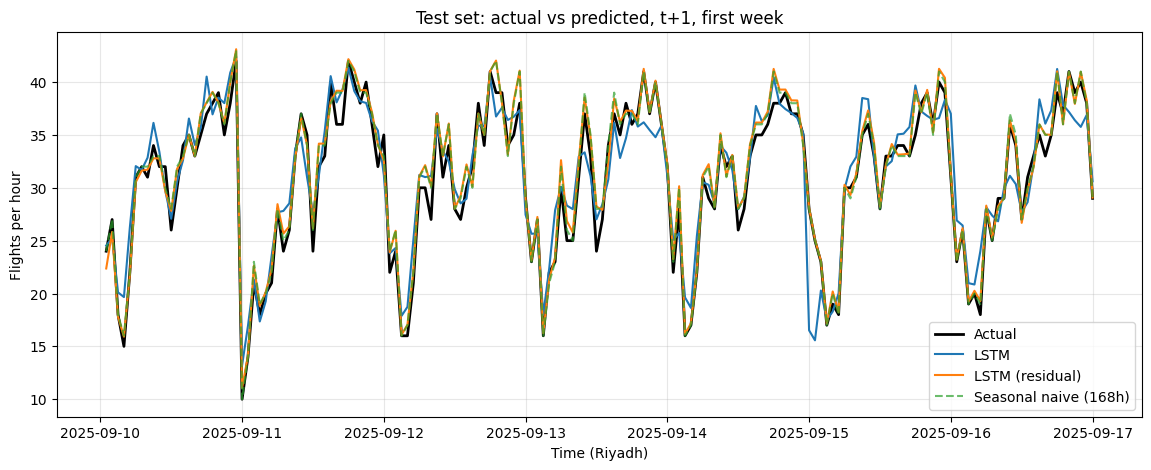

In [7]:
d_plain = DETAILS[(NAME_FULL, 'LSTM', SEEDS[0])]
d_res = DETAILS[(NAME_FULL, 'LSTM (residual)', SEEDS[0])]

n = 168
x = (d_plain['hour'].iloc[:n] + pd.Timedelta(hours=1)).dt.tz_convert('Asia/Riyadh').dt.tz_localize(None)

plt.figure(figsize=(14, 5))
plt.plot(x, d_plain['true_1'].iloc[:n], label='Actual', color='black', linewidth=2)
plt.plot(x, d_plain['pred_1'].iloc[:n], label='LSTM')
plt.plot(x, d_res['pred_1'].iloc[:n], label='LSTM (residual)')
plt.plot(x, d_plain['seas_1'].iloc[:n], '--', label='Seasonal naive (168h)', alpha=0.7)
plt.xlabel('Time (Riyadh)')
plt.ylabel('Flights per hour')
plt.title('Test set: actual vs predicted, t+1, first week')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### High-pressure hour detection (on the test set)

An hour counts as **high pressure** when its flight count is at least the 75th percentile of the training period. Precision, recall and F1 are computed on the test set for each model (mean over seeds). This is the simple binary version — the data-driven 3-tier version follows right after.

In [8]:
(tr_a, tr_b), _, _ = split_by_time(traffic)
thr = traffic.iloc[tr_a:tr_b]['flight_count'].quantile(0.75)

d0 = DETAILS[(NAME_FULL, 'LSTM', SEEDS[0])]
print(f"High pressure = at least {thr:.0f} flights per hour (75th percentile of training data)")
print(f"Share of high-pressure hours in the test set: {(d0['true_1'] >= thr).mean():.1%}\n")

display(pressure_table(NAME_FULL, thr))

High pressure = at least 35 flights per hour (75th percentile of training data)
Share of high-pressure hours in the test set: 35.0%



,horizon,model,precision,recall,F1
0,t+1,LSTM,0.811,0.817,0.814
1,t+1,LSTM (residual),0.921,0.889,0.905
2,t+1,Seasonal naive (168h),0.901,0.929,0.915
3,t+1,Persistence,0.697,0.694,0.695
4,t+2,LSTM,0.813,0.834,0.823
5,t+2,LSTM (residual),0.931,0.883,0.906
6,t+2,Seasonal naive (168h),0.902,0.930,0.915
7,t+2,Persistence,0.594,0.590,0.592
8,t+3,LSTM,0.794,0.852,0.821
9,t+3,LSTM (residual),0.918,0.894,0.905


### Data-driven pressure levels (NORMAL / HIGH / EXTREME)

The proposal calls for pressure levels **derived from clustering** historical traffic patterns, not a single fixed threshold. Traffic is clustered into 6 fine-grained groups by hourly flight count, which are then merged from busiest to quietest into three operational tiers sized so **EXTREME stays a genuinely rare, busiest-of-the-busy condition** (~10% of hours) rather than close to half of them, HIGH covers the next band (~25%), and NORMAL is the remaining majority (~65%). The cut points between tiers are still the midpoints between actual cluster centers — clustering-derived, not a hand-picked percentile.

In [9]:
train_counts = traffic.iloc[tr_a:tr_b]['flight_count'].to_numpy(dtype=float)
centers, bounds = fit_pressure_tiers(train_counts, n_clusters=6, seed=42,
                                     extreme_target_share=0.10, high_target_share=0.35)

print("Fine-grained cluster centers (flights/hour), training period:",
     [round(c, 1) for c in centers])
print(f"NORMAL  : < {bounds[0]:.1f} flights/hour")
print(f"HIGH    : {bounds[0]:.1f} - {bounds[1]:.1f} flights/hour")
print(f"EXTREME : >= {bounds[1]:.1f} flights/hour\n")

actual_tier = TIER_NAMES[classify_tier(d0['true_1'], bounds)]
share = pd.Series(actual_tier).value_counts(normalize=True).reindex(TIER_NAMES, fill_value=0) * 100
print("Share of test hours per tier (t+1, actual):")
display(share.round(1).rename('% of hours'))

print("\nRecommended action per tier:")
for tname in TIER_NAMES:
    print(f"  {tname:8s} -> {TIER_RECOMMENDATIONS[tname]}")

print("\nTier detection performance (mean over seeds):")
display(pressure_tier_table(NAME_FULL, bounds))

Fine-grained cluster centers (flights/hour), training period: [np.float64(12.8), np.float64(19.4), np.float64(25.4), np.float64(30.0), np.float64(34.6), np.float64(39.0)]
NORMAL  : < 32.3 flights/hour
HIGH    : 32.3 - 36.8 flights/hour
EXTREME : >= 36.8 flights/hour

Share of test hours per tier (t+1, actual):


,% of hours
NORMAL,52.3
HIGH,24.4
EXTREME,23.3



Recommended action per tier:
  NORMAL   -> Maintain standard operational readiness.
  HIGH     -> Prepare additional operational resources and monitor upcoming traffic.
  EXTREME  -> Prioritize resource readiness and prepare for sustained high activity.

Tier detection performance (mean over seeds):


,horizon,model,tier_accuracy,HIGH+_recall,EXTREME_recall
0,t+1,LSTM,0.739,0.906,0.626
1,t+1,LSTM (residual),0.853,0.947,0.835
2,t+1,Seasonal naive (168h),0.863,0.945,0.871
3,t+1,Persistence,0.653,0.787,0.541
4,t+2,LSTM,0.739,0.896,0.615
5,t+2,LSTM (residual),0.858,0.948,0.845
6,t+2,Seasonal naive (168h),0.863,0.946,0.871
7,t+2,Persistence,0.558,0.679,0.459
8,t+3,LSTM,0.747,0.901,0.704
9,t+3,LSTM (residual),0.858,0.952,0.861


# Part 1B: Does the result hold in other months? (walk-forward check)

Part 1 tests on a single window (September to October). Here `LSTM (residual)` is retrained and retested on two earlier windows, always using only data from before that window, so the result isn't resting on one lucky or unlucky period.

In [10]:
def walk_forward_splits(df, horizon=HORIZON):
    """3 folds, each testing on a later 10% slice, using only earlier data to train/validate."""
    n = len(df)
    folds = []
    for train_frac in (0.60, 0.70, 0.80):
        train_end = int(n * train_frac)
        val_end = int(n * (train_frac + 0.10))
        test_end = int(n * (train_frac + 0.20))
        folds.append(((0, train_end - horizon),
                      (train_end, val_end - horizon),
                      (val_end, test_end)))
    return folds


def run_lstm_fold(df, feature_cols, run_name, seed, split, residual=False,
                   window=WINDOW, epochs=100, batch_size=64,
                   units1=64, units2=32, dropout=0.2, learning_rate=0.001):
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    label = 'LSTM (residual)' if residual else 'LSTM'

    df = df.sort_values('hour').reset_index(drop=True)
    (tr_a, tr_b), (va_a, va_b), (te_a, te_b) = split
    seas1 = seasonal_reference(df['hour'], 1)

    cols = list(feature_cols)
    if residual:
        for k in range(3):
            df[f'seas_t{k + 1}'] = seas1[:, k]
        cols += ['seas_t1', 'seas_t2', 'seas_t3']

    true_raw = df[TARGET_COLS].to_numpy(dtype=float)
    base = seas1 if residual else np.zeros_like(seas1)
    y_model = true_raw - base

    sx = StandardScaler().fit(df.iloc[tr_a:tr_b][cols])
    sy = StandardScaler().fit(y_model[tr_a:tr_b])

    feats = sx.transform(df[cols])
    targs = sy.transform(y_model)
    cur = df['flight_count'].to_numpy(dtype=float)
    hrs = ((df['hour'] - df['hour'].iloc[0]).dt.total_seconds() / 3600).to_numpy()

    X_tr, y_tr, _, _ = make_windows(feats, targs, cur, hrs, window, tr_a, tr_b)
    X_va, y_va, _, _ = make_windows(feats, targs, cur, hrs, window, va_a, va_b)
    X_te, y_te, _, end_te = make_windows(feats, targs, cur, hrs, window, te_a, te_b)
    if len(X_te) == 0:
        return pd.DataFrame()

    model = build_model(window, len(cols), units1, units2, dropout, learning_rate)
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=epochs,
              batch_size=batch_size, callbacks=[early_stop], verbose=0)

    pred = sy.inverse_transform(model.predict(X_te, verbose=0)) + base[end_te]
    true = true_raw[end_te]
    seasonal = seas1[end_te]

    rows = []
    for i, h in enumerate(['t+1', 't+2', 't+3']):
        for model_name, p in [(label, pred), ('Seasonal naive (168h)', seasonal)]:
            mae, rmse, smape = score(true[:, i], p[:, i])
            rows.append({'dataset': run_name, 'model': model_name, 'horizon': h,
                         'MAE': mae, 'sMAPE': smape, 'n_test': len(true), 'seed': seed})
    return pd.DataFrame(rows)


FOLD_SEEDS = [1, 2, 3]
folds = walk_forward_splits(traffic)
fold_results = []
for i, split in enumerate(folds):
    (_, tb), (_, vb), (ta, te) = split
    name = f"Fold {i+1}"
    print(f"{name}: test period {traffic['hour'].iloc[ta]} -> {traffic['hour'].iloc[te-1]}")
    for s in FOLD_SEEDS:
        fold_results.append(run_lstm_fold(traffic, feature_cols, name, s, split,
                                          residual=True, **BEST_PARAMS))

fold_results = pd.concat(fold_results, ignore_index=True)
display(
    fold_results.groupby(['dataset', 'model', 'horizon'])[['MAE', 'sMAPE']]
    .agg(['mean', 'std']).round(3)
)

Fold 1: test period 2025-08-10 12:00:00+00:00 -> 2025-08-30 17:00:00+00:00
Fold 2: test period 2025-08-30 18:00:00+00:00 -> 2025-09-19 23:00:00+00:00
Fold 3: test period 2025-09-20 00:00:00+00:00 -> 2025-10-10 05:00:00+00:00


MAE         sMAPE       
                                        mean    std   mean    std
dataset model                 horizon                            
Fold 1  LSTM (residual)       t+1      1.350  0.032  4.812  0.156
                              t+2      1.427  0.043  5.103  0.179
                              t+3      1.508  0.089  5.444  0.411
        Seasonal naive (168h) t+1      1.671  0.000  6.656  0.000
                              t+2      1.671  0.000  6.656  0.000
                              t+3      1.671  0.000  6.656  0.000
Fold 2  LSTM (residual)       t+1      1.294  0.041  4.278  0.176
                              t+2      1.266  0.038  4.176  0.148
                              t+3      1.298  0.043  4.288  0.172
        Seasonal naive (168h) t+1      1.191  0.000  3.864  0.000
                              t+2      1.193  0.000  3.874  0.000
                              t+3      1.191  0.000  3.868  0.000
Fold 3  LSTM (residual)       t+1      1.161  0.029  4.054  0.132
                              t+2      1.160  0.049  4.064  0.227
                              t+3      1.194  0.034  4.170  0.146
        Seasonal naive (168h) t+1      1.093  0.000  3.780  0.000
                              t+2      1.091  0.000  3.771  0.000
                              t+3      1.103  0.000  3.810  0.000

**How to read this:** if `LSTM (residual)` stays close to `Seasonal naive` in every fold, the Part 1 result is a stable pattern, not a fluke of one window. A fold that looks very different likely hit a schedule disruption (cross-check against Part 3B).

# Part 2: Traffic-only vs Traffic + Weather

Uses `model_ready_weather.csv` (3,700 rows, the period with both traffic and observed weather). Test period here is **August**, so these numbers are not comparable with Part 1's September-October test.

In [11]:
runs_w = []
for a in (False, True):
    runs_w.append(run_seeds(weather_data, feature_cols, 'Traffic-only', residual=a, **BEST_PARAMS))
    runs_w.append(run_seeds(weather_data, feature_cols + weather_features,
                            'Traffic + Weather', residual=a, **BEST_PARAMS))
res_weather = pd.concat(runs_w, ignore_index=True)

done: Traffic-only | LSTM | seed 1 | epochs 20
done: Traffic-only | LSTM | seed 2 | epochs 26
done: Traffic-only | LSTM | seed 3 | epochs 26
done: Traffic-only | LSTM | seed 4 | epochs 23
done: Traffic-only | LSTM | seed 5 | epochs 14
done: Traffic + Weather | LSTM | seed 1 | epochs 21
done: Traffic + Weather | LSTM | seed 2 | epochs 16
done: Traffic + Weather | LSTM | seed 3 | epochs 19
done: Traffic + Weather | LSTM | seed 4 | epochs 18
done: Traffic + Weather | LSTM | seed 5 | epochs 14
done: Traffic-only | LSTM (residual) | seed 1 | epochs 32
done: Traffic-only | LSTM (residual) | seed 2 | epochs 16
done: Traffic-only | LSTM (residual) | seed 3 | epochs 18
done: Traffic-only | LSTM (residual) | seed 4 | epochs 16
done: Traffic-only | LSTM (residual) | seed 5 | epochs 20
done: Traffic + Weather | LSTM (residual) | seed 1 | epochs 23
done: Traffic + Weather | LSTM (residual) | seed 2 | epochs 22
done: Traffic + Weather | LSTM (residual) | seed 3 | epochs 23
done: Traffic + Weather | 

## Part 2 results

`mean diff (W - T)` is traffic + weather minus traffic-only, in flights per hour. The verdict flags a difference as clear only when it exceeds 2 standard errors over the 5 seeds.

In [12]:
print("Traffic-only models and baselines on the weather-period test set:")
display(summarize(res_weather[res_weather['dataset'] == 'Traffic-only']))

print("\nTraffic + Weather models and baselines on the weather-period test set:")
display(summarize(res_weather[res_weather['dataset'] == 'Traffic + Weather']))

for label in ['LSTM', 'LSTM (residual)']:
    print(f"\nWeather effect, {label}:")
    display(compare_weather(res_weather, label))

Traffic-only models and baselines on the weather-period test set:


MAE  MAE_std   RMSE   sMAPE  n_test
horizon model                                                          
t+1     LSTM                      3.033    0.107  4.292  11.065     492
        LSTM (residual)           1.485    0.042  2.445   5.665     492
        Persistence               4.126    0.000  5.648  14.668     492
        Seasonal avg (168h+336h)  1.727    0.000  3.417   6.837     492
        Seasonal naive (168h)     1.902    0.000  4.103   7.932     492
t+2     LSTM                      3.002    0.103  4.342  11.026     492
        LSTM (residual)           1.561    0.067  2.676   6.001     492
        Persistence               5.333    0.000  7.089  18.948     492
        Seasonal avg (168h+336h)  1.737    0.000  3.429   6.874     492
        Seasonal naive (168h)     1.898    0.000  4.102   7.922     492
t+3     LSTM                      2.947    0.107  4.334  10.970     492
        LSTM (residual)           1.683    0.046  2.988   6.465     492
        Persistence               6.571    0.000  8.585  22.847     492
        Seasonal avg (168h+336h)  1.745    0.000  3.443   6.906     492
        Seasonal naive (168h)     1.892    0.000  4.097   7.907     492


Traffic + Weather models and baselines on the weather-period test set:


MAE  MAE_std   RMSE   sMAPE  n_test
horizon model                                                          
t+1     LSTM                      3.187    0.077  4.382  11.466     492
        LSTM (residual)           1.608    0.048  2.864   6.291     492
        Persistence               4.126    0.000  5.648  14.668     492
        Seasonal avg (168h+336h)  1.727    0.000  3.417   6.837     492
        Seasonal naive (168h)     1.902    0.000  4.103   7.932     492
t+2     LSTM                      3.181    0.043  4.391  11.520     492
        LSTM (residual)           1.683    0.074  3.104   6.695     492
        Persistence               5.333    0.000  7.089  18.948     492
        Seasonal avg (168h+336h)  1.737    0.000  3.429   6.874     492
        Seasonal naive (168h)     1.898    0.000  4.102   7.922     492
t+3     LSTM                      3.085    0.126  4.365  11.392     492
        LSTM (residual)           1.822    0.110  3.382   7.354     492
        Persistence               6.571    0.000  8.585  22.847     492
        Seasonal avg (168h+336h)  1.745    0.000  3.443   6.906     492
        Seasonal naive (168h)     1.892    0.000  4.097   7.907     492


Weather effect, LSTM:


,MAE traffic-only,MAE traffic+weather,mean diff (W - T),SE of diff,verdict
horizon,,,,,
t+1,3.033,3.187,0.154,0.055,weather worse
t+2,3.002,3.181,0.179,0.032,weather worse
t+3,2.947,3.085,0.138,0.058,weather worse



Weather effect, LSTM (residual):


,MAE traffic-only,MAE traffic+weather,mean diff (W - T),SE of diff,verdict
horizon,,,,,
t+1,1.485,1.608,0.123,0.013,weather worse
t+2,1.561,1.683,0.122,0.034,weather worse
t+3,1.683,1.822,0.139,0.053,weather worse


### Test results — Traffic + Weather dataset (report table)

Clean MAE / RMSE / sMAPE(%) by forecast horizon for `LSTM (residual)`, side by side: the **traffic-only** run vs the **traffic + weather** run, both on the same August test set. Ready to paste into the report.

In [ ]:
print("TEST RESULTS — Traffic-only (weather-period test set)")
display(test_results_table(res_weather, 'Traffic-only', model_label='LSTM (residual)'))

print("\nTEST RESULTS — Traffic + Weather")
display(test_results_table(res_weather, 'Traffic + Weather', model_label='LSTM (residual)'))

TEST RESULTS — Traffic-only (weather-period test set)


,MAE,RMSE,sMAPE (%)
Forecast Horizon,,,
t+1,1.550,2.557,5.880
t+2,1.610,2.734,6.182
t+3,1.751,3.051,6.647



TEST RESULTS — Traffic + Weather


,MAE,RMSE,sMAPE (%)
Forecast Horizon,,,
t+1,1.652,2.929,6.423
t+2,1.761,3.172,6.878
t+3,1.874,3.445,7.311


# Part 3: Diagnostics

**3A.** Did the weather shift between training and test? **3B.** Which days did the seasonal baseline get most wrong?

In [13]:
(w_a, w_b), _, (w_f, w_g) = split_by_time(weather_data)
train_part = weather_data.iloc[w_a:w_b]
test_part = weather_data.iloc[w_f:w_g]

print("TRAIN:", train_part['hour'].min(), "->", train_part['hour'].max())
print("TEST: ", test_part['hour'].min(), "->", test_part['hour'].max(), "\n")

shift = pd.DataFrame({
    'train min': train_part[weather_features].min(),
    'train max': train_part[weather_features].max(),
    'test min': test_part[weather_features].min(),
    'test max': test_part[weather_features].max(),
    'train mean': train_part[weather_features].mean(),
    'test mean': test_part[weather_features].mean(),
})
shift['mean shift (train std units)'] = (
    (shift['test mean'] - shift['train mean']) / train_part[weather_features].std()
)
shift['% test rows outside train range'] = [
    ((test_part[f] < train_part[f].min()) | (test_part[f] > train_part[f].max())).mean() * 100
    for f in weather_features
]
display(shift.round(2))

TRAIN: 2025-03-21 21:00:00+00:00 -> 2025-07-09 02:00:00+00:00
TEST:  2025-08-01 14:00:00+00:00 -> 2025-08-24 21:00:00+00:00 



,train min,train max,test min,test max,train mean,test mean,mean shift (train std units),% test rows outside train range
air_temperature,10.85,46.0,26.9,46.0,32.60,37.76,0.76,0.00
wind_speed_rate,0.00,10.3,0.0,8.8,2.96,3.12,0.10,0.00
visibility_distance,400.00,10000.0,1600.0,9999.5,9398.14,8793.76,-0.36,0.00
air_temperature_dew_point,-14.00,20.0,-15.0,17.0,-4.03,-0.90,0.68,0.36


In [14]:
d = DETAILS[('Traffic-only', 'LSTM', SEEDS[0])].copy()
d['target_hour'] = (d['hour'] + pd.Timedelta(hours=1)).dt.tz_convert('Asia/Riyadh')
d['seas_err'] = (d['true_1'] - d['seas_1']).abs()
d['lstm_err'] = (d['true_1'] - d['pred_1']).abs()
d['date'] = d['target_hour'].dt.date

print("Days with the largest seasonal-naive error (mean abs error per day, t+1):")
daily = d.groupby('date')[['seas_err', 'lstm_err']].mean().round(2)
display(daily.sort_values('seas_err', ascending=False).head(8))

Days with the largest seasonal-naive error (mean abs error per day, t+1):


,seas_err,lstm_err
date,,
2025-08-17,7.21,2.26
2025-08-10,7.21,4.03
2025-08-21,5.50,3.68
2025-08-14,5.29,4.15
2025-08-06,2.17,3.28
2025-08-01,2.00,3.49
2025-08-03,1.46,2.37
2025-08-23,1.08,2.22


# Part 5: Operational Feedback for the Airport Team

This turns the `LSTM (residual)` model's **test-set** predictions (data it never trained on) into a plain-language report: how well it forecasts busy hours 1 hour ahead, what that means in practice, where it needs a human check, and what pressure level — with what recommended action — each hour falls into.

Daily breakdown (first 14 days of the test period):


,date,actual_high_hours,caught,missed,false_alarms,extreme_hours
0,2025-09-10,8,7,1,0,5
1,2025-09-11,10,9,1,0,6
2,2025-09-12,8,7,1,2,6
3,2025-09-13,10,10,0,0,7
4,2025-09-14,9,8,1,0,5
5,2025-09-15,8,8,0,0,4
6,2025-09-16,9,9,0,1,6
7,2025-09-17,6,5,1,1,3
8,2025-09-18,10,9,1,0,8
9,2025-09-19,7,7,0,1,6


Hours per pressure tier in the test period (actual vs. predicted):


,actual,predicted
NORMAL,381,367
HIGH,178,192
EXTREME,170,170


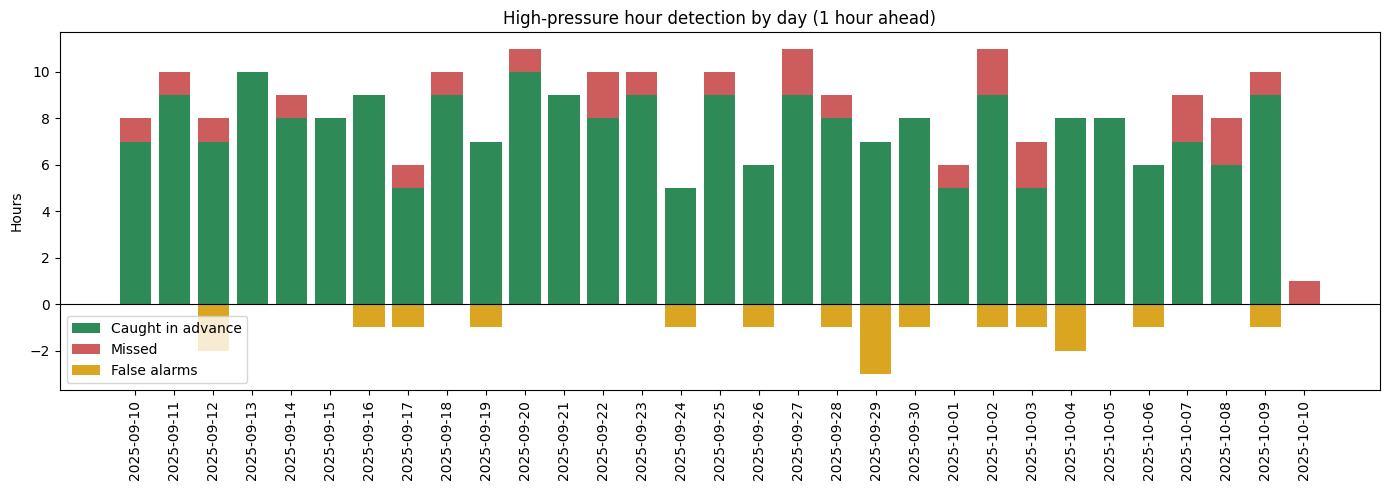


OPERATIONAL SUMMARY
--------------------
Test period: 2025-09-10 to 2025-10-10 (31 days)
Forecast horizon: 1 hour ahead

Typical error: 1.1 flights/hour off, against an average
of 31 flights/hour in this period.

High-pressure threshold: 35+ flights/hour (35% of test hours
qualified as high-pressure).

Of the 255 genuinely high-pressure hours in the test period, the model
flagged 90% of them at least 1 hour ahead (230 caught, 25 missed).
Of the hours it flagged as high-pressure, 93% actually were (18 false alarms
out of 729 test hours, or 2.5% of the time).

DATA-DRIVEN PRESSURE LEVELS (clustering on training-period traffic)
NORMAL  : < 32 flights/hour  -> Maintain standard operational readiness.
HIGH    : 32-37 flights/hour -> Prepare additional operational resources and monitor upcoming traffic.
EXTREME : >= 37 flights/hour -> Prioritize resource readiness and prepare for sustained high activity.

Actual hours by tier: NORMAL 381, HIGH 178,
EXTREME 170. The model assigned the exact 

In [15]:
model_label = 'LSTM (residual)'
k = 1  # forecasting 1 hour ahead — the most actionable lead time for staffing

frames = [DETAILS[(NAME_FULL, model_label, s)] for s in SEEDS]
avg_pred = np.mean([f[f'pred_{k}'].to_numpy() for f in frames], axis=0)
ref = frames[0]  # actual values and timestamps are identical across seeds

ops = pd.DataFrame({
    'target_hour': (ref['hour'] + pd.Timedelta(hours=k)).dt.tz_convert('Asia/Riyadh'),
    'actual': ref[f'true_{k}'],
    'predicted': avg_pred,
})
ops['abs_error'] = (ops['actual'] - ops['predicted']).abs()
ops['actual_high'] = ops['actual'] >= thr
ops['predicted_high'] = ops['predicted'] >= thr
ops['hit'] = ops['actual_high'] & ops['predicted_high']
ops['missed'] = ops['actual_high'] & ~ops['predicted_high']
ops['false_alarm'] = ~ops['actual_high'] & ops['predicted_high']

# --- Data-driven pressure tiers (NORMAL / HIGH / EXTREME) ---
ops['actual_tier'] = TIER_NAMES[classify_tier(ops['actual'], bounds)]
ops['predicted_tier'] = TIER_NAMES[classify_tier(ops['predicted'], bounds)]
ops['recommendation'] = ops['predicted_tier'].map(TIER_RECOMMENDATIONS)
ops['tier_match'] = ops['actual_tier'] == ops['predicted_tier']

tp, fn, fp = ops['hit'].sum(), ops['missed'].sum(), ops['false_alarm'].sum()
recall = tp / (tp + fn) if (tp + fn) else float('nan')
precision = tp / (tp + fp) if (tp + fp) else float('nan')

tier_accuracy = ops['tier_match'].mean()
tier_counts_actual = ops['actual_tier'].value_counts().reindex(TIER_NAMES, fill_value=0)
tier_counts_predicted = ops['predicted_tier'].value_counts().reindex(TIER_NAMES, fill_value=0)

# --- Day-by-day breakdown ---
ops['date'] = ops['target_hour'].dt.date
daily = ops.groupby('date').agg(
    actual_high_hours=('actual_high', 'sum'),
    caught=('hit', 'sum'),
    missed=('missed', 'sum'),
    false_alarms=('false_alarm', 'sum'),
    extreme_hours=('actual_tier', lambda s: (s == 'EXTREME').sum()),
).reset_index()

print("Daily breakdown (first 14 days of the test period):")
display(daily.head(14))

print("Hours per pressure tier in the test period (actual vs. predicted):")
display(pd.DataFrame({'actual': tier_counts_actual, 'predicted': tier_counts_predicted}))

# --- Visual for the ops team ---
plt.figure(figsize=(14, 5))
plt.bar(daily['date'].astype(str), daily['caught'], label='Caught in advance', color='seagreen')
plt.bar(daily['date'].astype(str), daily['missed'], bottom=daily['caught'],
        label='Missed', color='indianred')
plt.bar(daily['date'].astype(str), -daily['false_alarms'], label='False alarms', color='goldenrod')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=90)
plt.ylabel('Hours')
plt.title('High-pressure hour detection by day (1 hour ahead)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Written summary, generated from the actual numbers above ---
worst_day = daily.loc[daily['missed'].idxmax()]
print(f"""
OPERATIONAL SUMMARY
--------------------
Test period: {ops['target_hour'].min().date()} to {ops['target_hour'].max().date()} ({len(daily)} days)
Forecast horizon: 1 hour ahead

Typical error: {ops['abs_error'].mean():.1f} flights/hour off, against an average
of {ref['true_1'].mean():.0f} flights/hour in this period.

High-pressure threshold: {thr:.0f}+ flights/hour ({ops['actual_high'].mean():.0%} of test hours
qualified as high-pressure).

Of the {int(tp + fn)} genuinely high-pressure hours in the test period, the model
flagged {recall:.0%} of them at least 1 hour ahead ({int(tp)} caught, {int(fn)} missed).
Of the hours it flagged as high-pressure, {precision:.0%} actually were ({int(fp)} false alarms
out of {len(ops)} test hours, or {fp/len(ops):.1%} of the time).

DATA-DRIVEN PRESSURE LEVELS (clustering on training-period traffic)
NORMAL  : < {bounds[0]:.0f} flights/hour  -> {TIER_RECOMMENDATIONS['NORMAL']}
HIGH    : {bounds[0]:.0f}-{bounds[1]:.0f} flights/hour -> {TIER_RECOMMENDATIONS['HIGH']}
EXTREME : >= {bounds[1]:.0f} flights/hour -> {TIER_RECOMMENDATIONS['EXTREME']}

Actual hours by tier: NORMAL {tier_counts_actual['NORMAL']}, HIGH {tier_counts_actual['HIGH']},
EXTREME {tier_counts_actual['EXTREME']}. The model assigned the exact same tier as the
real outcome {tier_accuracy:.0%} of the time.

Practical read: the model gives a usable early-warning signal for staffing and
gate readiness, at the cost of an occasional false alarm. The day with the most
missed high-pressure hours was {worst_day['date']} ({int(worst_day['missed'])} missed)
-- worth a manual look, since it likely reflects a schedule change the model
was never told about (holiday, event, or timetable shift).

Caveat: these figures are based on the SCHEDULED flight timetable, not confirmed
actual arrival/departure times. The model reflects planned load, not real-time
delays or cancellations.
""")

# Limitations

- **Scheduled load, not real pressure.** The flight counts come from scheduled times. The dataset has no actual times (most `status` values are "Unknown"), so weather effects on delays and cancellations, and true real-time pressure, cannot be measured.
- **Different test periods.** Part 1 is tested on September to October, Part 2 on August (weather data ends August 24). Results across the two parts are not comparable. This is a limit of the data, not the method.
- **Weather experiment is not on the shared split.** The 3,700-row weather file gives a different 70/15/15 cut than the shared split by necessity, since it is a shorter series. It can only be compared with other models that run the same weather experiment on the same file.
- **Weather features show a mild negative effect here**, evidenced across 5 seeds, but limited to this one test window.
- **Walk-forward (Part 1B)** adds two more test windows to check robustness, but all three still come from the same 7-month dataset — a full year of data would be needed to test true seasonal generalization.
- **Pressure tiers are fit on training-period traffic** via fine-grained clustering merged into 3 bands (EXTREME ≈10% of hours, HIGH ≈25%, NORMAL ≈65%); these target shares are a modeling choice, and a different share or clustering method would shift the exact cut points.
- **Hyperparameter tuning (Part 0)** is a coordinate-wise search on a single seed, not an exhaustive grid, for runtime reasons — a full grid search or multi-seed tuning could find a marginally better configuration.